<a href="https://colab.research.google.com/github/Addreta/fermi-hubbard-quantum-sim/blob/main/1D_FHM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install quspin openfermion qiskit qiskit-aer qiskit-nature qiskit-algorithms



  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.5/38.5 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.9 MB/s eta 0:00:00
  Created wheel fo

Hermiticity check passed!
Symmetry checks passed!
Particle conservation check passed!


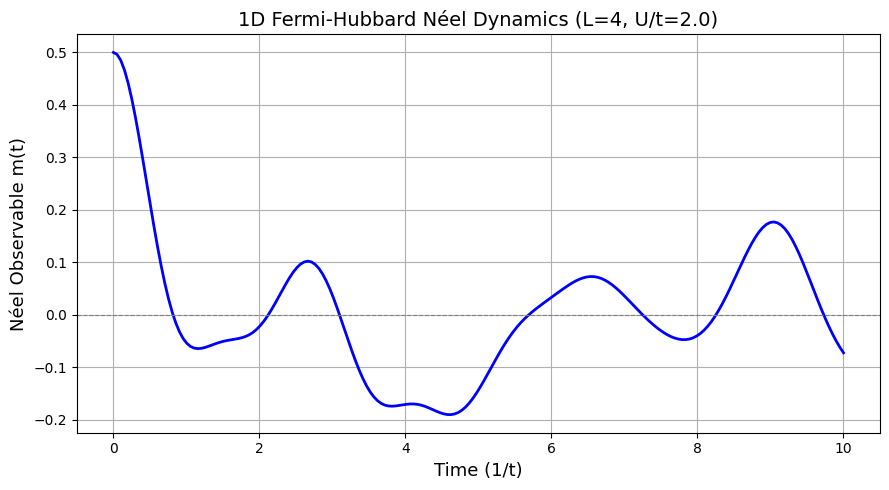

Initial Neel value: 0.5000
Long-time average:  0.0273


In [3]:
from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 4
t_hop = 1.0
U = 2.0
N_up = 2
N_down = 2

# Build basis and Hamiltonian
basis = spinful_fermion_basis_1d(L, Nf=(N_up, N_down))
hop = [[-t_hop, i, i+1] for i in range(L-1)] + [[-t_hop, i+1, i] for i in range(L-1)]
interaction = [[U, i, i] for i in range(L)]

static = [["+-|", hop], ["|+-", hop], ["n|n", interaction]]
H = hamiltonian(static, [], basis=basis, dtype=np.complex128)

# Neel state: up electrons on sites 0,2 → binary "1010"
#             down electrons on sites 1,3 → binary "0101"
neel_state = basis.index("1010", "0101")
psi0 = np.zeros(basis.Ns, dtype=np.complex128)
psi0[neel_state] = 1.0

# Time array
times = np.linspace(0, 10, 200)

# Build Sz operator for each site
def build_Sz(site, basis):
    n_up   = [[0.5,  site]]
    n_down = [[-0.5, site]]
    static_sz = [["n|", n_up], ["|n", n_down]]
    return hamiltonian(static_sz, [], basis=basis, dtype=np.complex128,
                       check_symm=False, check_herm=False, check_pcon=False)

Sz_ops = [build_Sz(i, basis) for i in range(L)]

# Time evolve
psi_t = H.evolve(psi0, 0, times)

# Measure Neel observable
neel_t = np.zeros(len(times))
for i in range(L):
    Sz_expect = np.real(np.einsum('it,ij,jt->t',
                        psi_t.conj(), Sz_ops[i].toarray(), psi_t))
    neel_t += ((-1)**i) * Sz_expect
neel_t /= L

# Plot
plt.figure(figsize=(9, 5))
plt.plot(times, neel_t, 'b-', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('Time (1/t)', fontsize=13)
plt.ylabel('Néel Observable m(t)', fontsize=13)
plt.title(f'1D Fermi-Hubbard Néel Dynamics (L={L}, U/t={U})', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.savefig('neel_dynamics_exact.png', dpi=150)
plt.show()

print(f"Initial Neel value: {neel_t[0]:.4f}")
print(f"Long-time average:  {np.mean(neel_t[100:]):.4f}")

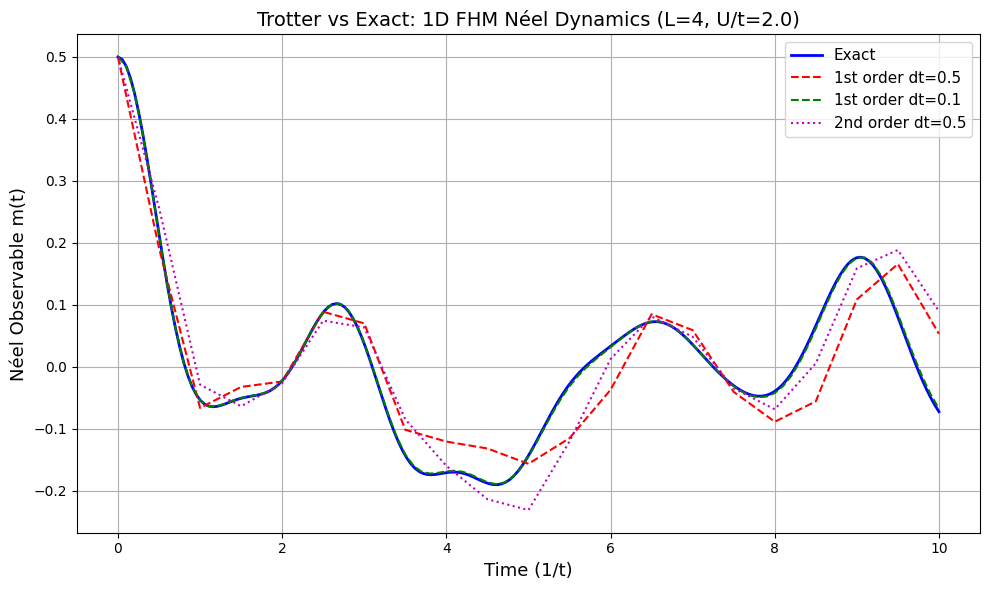

In [4]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
from openfermion.hamiltonians import fermi_hubbard
from openfermion.transforms import jordan_wigner
from scipy.linalg import expm
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 4
t_hop = 1.0
U = 2.0
n_qubits = 2 * L

# Build Hamiltonian
def openfermion_to_qiskit(qubit_operator, n_qubits):
    pauli_list = []
    for term, coeff in qubit_operator.terms.items():
        if abs(coeff) < 1e-10:
            continue
        pauli_str = ['I'] * n_qubits
        for qubit_idx, pauli in term:
            pauli_str[qubit_idx] = pauli
        pauli_str = ''.join(reversed(pauli_str))
        pauli_list.append((pauli_str, coeff.real))
    return SparsePauliOp.from_list(pauli_list)

fh_operator = fermi_hubbard(x_dimension=L, y_dimension=1,
                             tunneling=t_hop, coulomb=U, periodic=False)
jw_operator = jordan_wigner(fh_operator)
H_qiskit = openfermion_to_qiskit(jw_operator, n_qubits)
H_matrix = H_qiskit.to_matrix()

pauli_list = H_qiskit.to_list()
H_hop_matrix = SparsePauliOp.from_list([(p,c) for p,c in pauli_list if 'X' in p or 'Y' in p]).to_matrix()
H_int_matrix = SparsePauliOp.from_list([(p,c) for p,c in pauli_list if 'X' not in p and 'Y' not in p]).to_matrix()

# Correct Neel initial state
qc_init = QuantumCircuit(n_qubits)
for q in [0, 4, 3, 7]:
    qc_init.x(q)
psi0 = Statevector(qc_init).data

# Sz operators
def build_Sz_matrix(site, n_qubits):
    up_qubit   = 2 * site
    down_qubit = 2 * site + 1
    up_str   = 'I'*(n_qubits-up_qubit-1)   + 'Z' + 'I'*up_qubit
    down_str = 'I'*(n_qubits-down_qubit-1) + 'Z' + 'I'*down_qubit
    return SparsePauliOp.from_list([(up_str, -0.25), (down_str, 0.25)]).to_matrix()

Sz_matrices = [build_Sz_matrix(i, n_qubits) for i in range(L)]

def measure_neel(psi):
    return sum(((-1)**i) * np.real(psi.conj() @ Sz_matrices[i] @ psi) for i in range(L)) / L

# Exact time evolution
t_max = 10.0
times_exact = np.linspace(0, t_max, 200)
neel_exact = [measure_neel(expm(-1j * t * H_matrix) @ psi0) for t in times_exact]

# Trotter evolution
def trotter_evolve(psi0, dt, n_steps, order=1):
    psi = psi0.copy()
    if order == 1:
        U_hop = expm(-1j * dt * H_hop_matrix)
        U_int = expm(-1j * dt * H_int_matrix)
        step = lambda p: U_hop @ (U_int @ p)
    else:
        U_hop_half = expm(-1j * (dt/2) * H_hop_matrix)
        U_int_full = expm(-1j * dt * H_int_matrix)
        step = lambda p: U_hop_half @ (U_int_full @ (U_hop_half @ p))
    states = [psi.copy()]
    for _ in range(n_steps):
        psi = step(psi)
        states.append(psi.copy())
    return np.array(states)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(times_exact, neel_exact, 'b-', linewidth=2, label='Exact')

configs = [
    (0.5, int(t_max/0.5), '1st order dt=0.5', 'r--',  1),
    (0.1, int(t_max/0.1), '1st order dt=0.1', 'g--',  1),
    (0.5, int(t_max/0.5), '2nd order dt=0.5', 'm:',   2),
]

for dt, n_steps, label, style, order in configs:
    times_tr = np.linspace(0, t_max, n_steps+1)
    states = trotter_evolve(psi0, dt, n_steps, order=order)
    neel_tr = [measure_neel(psi) for psi in states]
    plt.plot(times_tr, neel_tr, style, linewidth=1.5, label=label)

plt.xlabel('Time (1/t)', fontsize=13)
plt.ylabel('Néel Observable m(t)', fontsize=13)
plt.title(f'Trotter vs Exact: 1D FHM Néel Dynamics (L={L}, U/t={U})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.savefig('trotter_vs_exact.png', dpi=150)
plt.show()

In [8]:
import numpy as np
from scipy.linalg import expm
from itertools import product

# ── System: 2-site Hubbard, half-filling (1 up, 1 dn) ──────────────────────
# Basis: |↑↓,0⟩, |↑,↓⟩, |↓,↑⟩, |0,↑↓⟩  (4 states)
t_hop = 1.0
U     = 4.0

H_hop_matrix = np.array([
    [0,  -t_hop, -t_hop,  0],
    [-t_hop, 0,  0,  -t_hop],
    [-t_hop, 0,  0,  -t_hop],
    [0,  -t_hop, -t_hop,  0]
], dtype=complex)

H_int_matrix = np.diag([U, 0, 0, U]).astype(complex)

H_matrix = H_hop_matrix + H_int_matrix

# ── Initial state: |↑,↓⟩  (index 1) ───────────────────────────────────────
psi0 = np.zeros(4, dtype=complex)
psi0[1] = 1.0

# ── Trotter benchmark ───────────────────────────────────────────────────────
t_fixed   = 2.0
dt_values = [0.5, 0.25, 0.1, 0.05, 0.02, 0.01]

print("Checking state-level error instead of observable error:")
print(f"{'dt':>8} | {'1st order':>10} | {'2nd order':>10} | {'ratio':>6}")
print("-" * 48)

errors_1st_state = []
errors_2nd_state = []

psi_exact_t = expm(-1j * t_fixed * H_matrix) @ psi0   # compute once

for dt in dt_values:
    n_steps = int(round(t_fixed / dt))

    # 1st order: U_int · U_hop
    psi = psi0.copy()
    U_hop = expm(-1j * dt * H_hop_matrix)
    U_int = expm(-1j * dt * H_int_matrix)
    for _ in range(n_steps):
        psi = U_int @ (U_hop @ psi)
    e1 = np.linalg.norm(psi - psi_exact_t)
    errors_1st_state.append(e1)

    # 2nd order (Strang): U_hop/2 · U_int · U_hop/2
    psi = psi0.copy()
    U_hop_half = expm(-1j * (dt / 2) * H_hop_matrix)
    U_int_full = expm(-1j * dt * H_int_matrix)
    for _ in range(n_steps):
        psi = U_hop_half @ (U_int_full @ (U_hop_half @ psi))
    e2 = np.linalg.norm(psi - psi_exact_t)
    errors_2nd_state.append(e2)

    print(f"{dt:>8.3f} | {e1:>10.2e} | {e2:>10.2e} | {e1/e2:>6.2f}")

slope_1st = np.polyfit(np.log(dt_values), np.log(errors_1st_state), 1)[0]
slope_2nd = np.polyfit(np.log(dt_values), np.log(errors_2nd_state), 1)[0]

print(f"\n1st order slope: {slope_1st:.2f}  (expected ~1.0)")
print(f"2nd order slope: {slope_2nd:.2f}  (expected ~2.0)")

Checking state-level error instead of observable error:
      dt |  1st order |  2nd order |  ratio
------------------------------------------------
   0.500 |   5.74e-01 |   4.18e-01 |   1.37
   0.250 |   1.85e-01 |   9.17e-02 |   2.02
   0.100 |   6.12e-02 |   1.41e-02 |   4.35
   0.050 |   2.96e-02 |   3.50e-03 |   8.47
   0.020 |   1.17e-02 |   5.59e-04 |  21.02
   0.010 |   5.86e-03 |   1.40e-04 |  42.00

1st order slope: 1.15  (expected ~1.0)
2nd order slope: 2.04  (expected ~2.0)


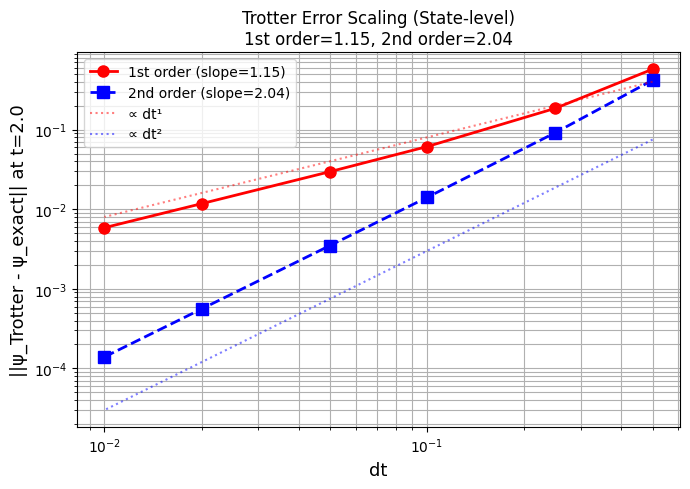

In [9]:
plt.figure(figsize=(7, 5))
plt.loglog(dt_values, errors_1st_state, 'ro-', linewidth=2, markersize=8, label=f'1st order (slope={slope_1st:.2f})')
plt.loglog(dt_values, errors_2nd_state, 'bs--', linewidth=2, markersize=8, label=f'2nd order (slope={slope_2nd:.2f})')

dt_arr = np.array(dt_values)
plt.loglog(dt_arr, 0.8*dt_arr**1, 'r:', alpha=0.5, label='∝ dt¹')
plt.loglog(dt_arr, 0.3*dt_arr**2, 'b:', alpha=0.5, label='∝ dt²')

plt.xlabel('dt', fontsize=13)
plt.ylabel(f'||ψ_Trotter - ψ_exact|| at t={t_fixed}', fontsize=13)
plt.title(f'Trotter Error Scaling (State-level)\n1st order={slope_1st:.2f}, 2nd order={slope_2nd:.2f}', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, which='both')
plt.tight_layout()
plt.savefig('trotter_scaling_state.png', dpi=150)
plt.show()

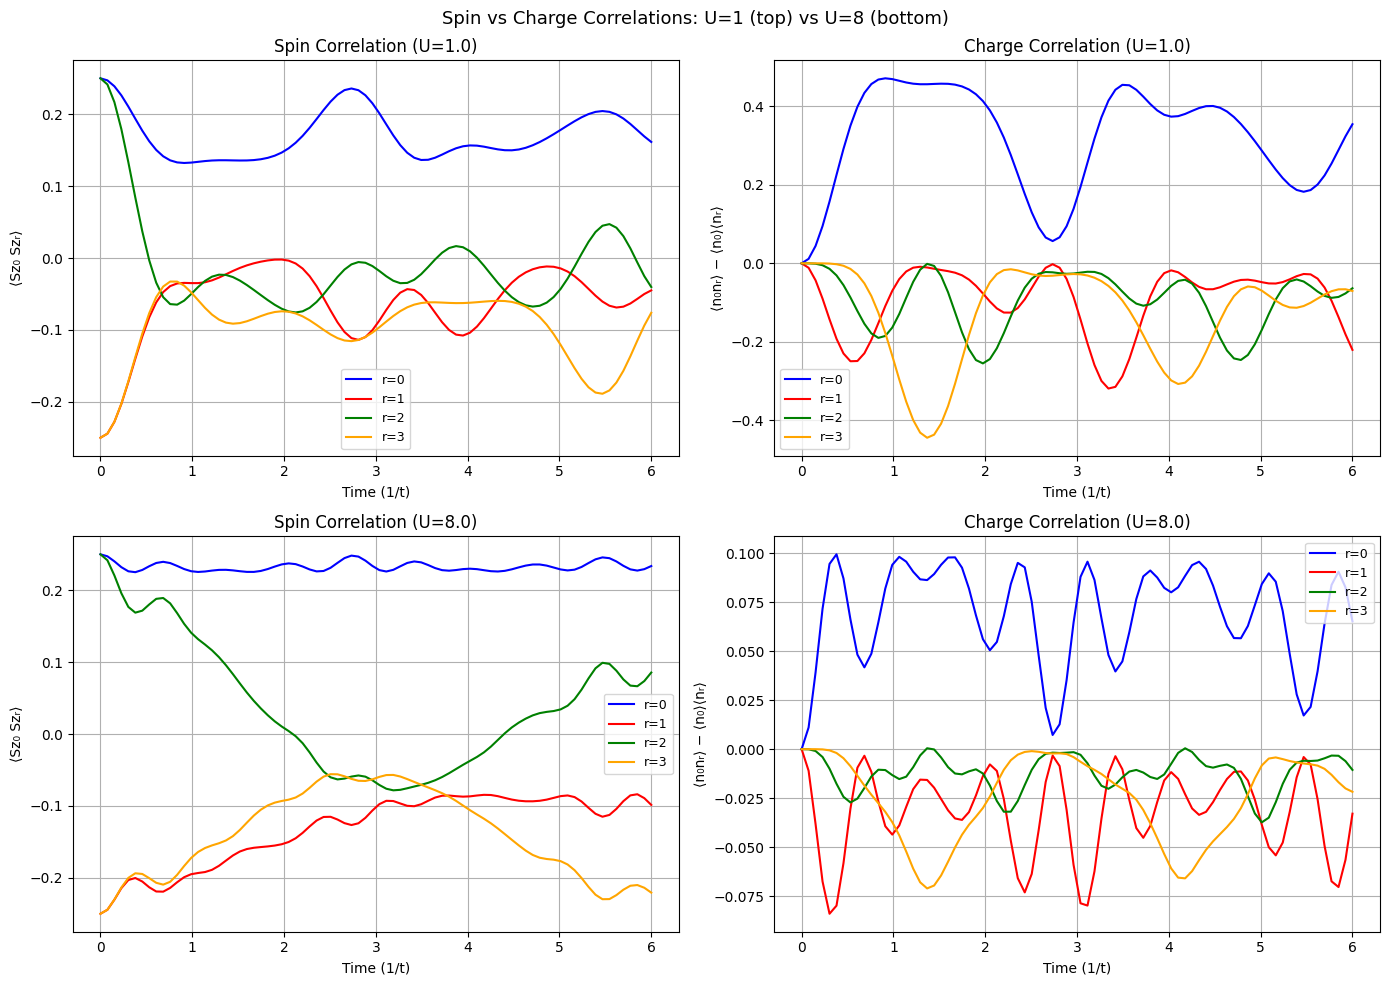

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from openfermion import fermi_hubbard, jordan_wigner
# assumes openfermion_to_qiskit and your import chain already done

# ── Parameters ──────────────────────────────────────────────────────────────
L       = 4
t_hop   = 1.0
times   = np.linspace(0, 6, 80)
n_qubits = 2 * L   # 8 qubits → 256-dim Hilbert space

# ── Build site-level operators in the full 2^n_qubits space ─────────────────
# OpenFermion JW convention: qubit 2r = spin-up at site r, 2r+1 = spin-down

I2 = np.eye(2, dtype=complex)
Z2 = np.array([[1, 0], [0, -1]], dtype=complex)

def embed(op_2x2, qubit):
    """Tensor-embed a single-qubit 2×2 op into the full n_qubits space."""
    mats = [I2] * n_qubits
    mats[qubit] = op_2x2
    out = mats[0]
    for m in mats[1:]:
        out = np.kron(out, m)
    return out

# n_j = (I - Z_j)/2  for each qubit j
nq = [0.5 * (embed(I2, j) - embed(Z2, j)) for j in range(n_qubits)]

# Site occupation and Sz
n_matrices  = [nq[2*r] + nq[2*r+1]            for r in range(L)]
Sz_matrices = [0.5 * (nq[2*r] - nq[2*r+1])   for r in range(L)]

# ── Initial state: Néel  ↑↓↑↓  at half-filling ──────────────────────────────
# JW bit string: q0=1,q1=0,q2=0,q3=1,q4=1,q5=0,q6=0,q7=1
# → index = 1·128 + 0·64 + 0·32 + 1·16 + 1·8 + 0·4 + 0·2 + 1·1 = 153
neel_idx = sum(bit * 2**(n_qubits - 1 - pos)
               for pos, bit in enumerate([1,0,0,1,1,0,0,1]))
psi0 = np.zeros(2**n_qubits, dtype=complex)
psi0[neel_idx] = 1.0

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_r  = ['blue', 'red', 'green', 'orange']

for u_idx, U in enumerate([1.0, 8.0]):
    fh   = fermi_hubbard(x_dimension=L, y_dimension=1,
                         tunneling=t_hop, coulomb=U, periodic=False)
    H_q  = openfermion_to_qiskit(jordan_wigner(fh), n_qubits)
    H_mat = H_q.to_matrix()

    spin_corr   = np.zeros((len(times), L))
    charge_corr = np.zeros((len(times), L))

    for ti, t in enumerate(times):
        psi_t = expm(-1j * t * H_mat) @ psi0
        n0  = np.real(psi_t.conj() @ n_matrices[0]  @ psi_t)
        for r in range(L):
            Sz0_Szr = np.real(psi_t.conj() @ (Sz_matrices[0] @ Sz_matrices[r]) @ psi_t)
            nr      = np.real(psi_t.conj() @ n_matrices[r] @ psi_t)
            n0_nr   = np.real(psi_t.conj() @ (n_matrices[0] @ n_matrices[r]) @ psi_t)
            spin_corr[ti, r]   = Sz0_Szr
            charge_corr[ti, r] = n0_nr - n0 * nr

    ax_s, ax_c = axes[u_idx, 0], axes[u_idx, 1]
    for r in range(L):
        ax_s.plot(times, spin_corr[:,   r], color=colors_r[r], lw=1.5, label=f'r={r}')
        ax_c.plot(times, charge_corr[:, r], color=colors_r[r], lw=1.5, label=f'r={r}')

    for ax, ylabel, title in [
        (ax_s, '⟨Sz₀ Szᵣ⟩',           f'Spin Correlation (U={U})'),
        (ax_c, '⟨n₀nᵣ⟩ − ⟨n₀⟩⟨nᵣ⟩',  f'Charge Correlation (U={U})')
    ]:
        ax.set(xlabel='Time (1/t)', ylabel=ylabel, title=title)
        ax.legend(fontsize=9); ax.grid(True)

plt.suptitle('Spin vs Charge Correlations: U=1 (top) vs U=8 (bottom)', fontsize=13)
plt.tight_layout()
plt.savefig('spin_charge_correlations.png', dpi=150)
plt.show()

U/t=  0.5  |  1st: 2.566e-02  |  2nd: 6.460e-04
U/t=  1.0  |  1st: 4.920e-02  |  2nd: 1.963e-03
U/t=  2.0  |  1st: 8.434e-02  |  2nd: 7.346e-03
U/t=  4.0  |  1st: 1.244e-01  |  2nd: 2.674e-02
U/t=  6.0  |  1st: 1.853e-01  |  2nd: 5.205e-02
U/t=  8.0  |  1st: 1.641e-01  |  2nd: 7.944e-02
U/t= 10.0  |  1st: 2.312e-01  |  2nd: 1.079e-01
U/t= 12.0  |  1st: 2.063e-01  |  2nd: 1.323e-01
U/t= 16.0  |  1st: 2.730e-01  |  2nd: 1.887e-01


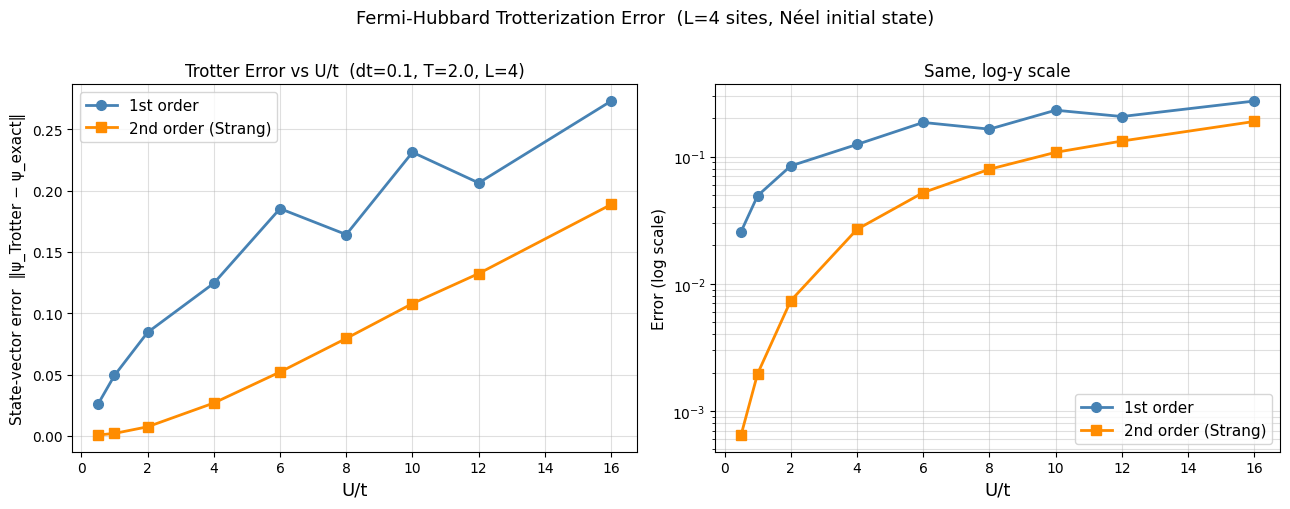

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from openfermion import fermi_hubbard, jordan_wigner
# assumes openfermion_to_qiskit is already imported/defined

# ── Parameters ───────────────────────────────────────────────────────────────
L        = 4
t_hop    = 1.0
n_qubits = 2 * L
t_fixed  = 2.0
dt       = 0.1
n_steps  = int(round(t_fixed / dt))

U_values   = np.array([0.5, 1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0])
UT_ratios  = U_values / t_hop

# ── Initial state: Néel ↑↓↑↓ ─────────────────────────────────────────────────
neel_idx = sum(bit * 2**(n_qubits - 1 - pos)
               for pos, bit in enumerate([1,0,0,1,1,0,0,1]))
psi0 = np.zeros(2**n_qubits, dtype=complex)
psi0[neel_idx] = 1.0

# ── Collect errors ────────────────────────────────────────────────────────────
err_1st = []
err_2nd = []

for U in U_values:
    fh    = fermi_hubbard(x_dimension=L, y_dimension=1,
                          tunneling=t_hop, coulomb=U, periodic=False)
    H_mat = openfermion_to_qiskit(jordan_wigner(fh), n_qubits).to_matrix()

    # Split into hopping (off-diag) and interaction (diag) parts
    H_hop = H_mat.copy(); np.fill_diagonal(H_hop, 0)
    H_int = np.diag(np.diag(H_mat)).astype(complex)

    psi_exact = expm(-1j * t_fixed * H_mat) @ psi0

    # 1st order: U_int · U_hop
    U_hop  = expm(-1j * dt * H_hop)
    U_int  = expm(-1j * dt * H_int)
    psi = psi0.copy()
    for _ in range(n_steps):
        psi = U_int @ (U_hop @ psi)
    err_1st.append(np.linalg.norm(psi - psi_exact))

    # 2nd order Strang: U_hop/2 · U_int · U_hop/2
    U_hop_h = expm(-1j * (dt/2) * H_hop)
    psi = psi0.copy()
    for _ in range(n_steps):
        psi = U_hop_h @ (U_int @ (U_hop_h @ psi))
    err_2nd.append(np.linalg.norm(psi - psi_exact))

    print(f"U/t={U/t_hop:5.1f}  |  1st: {err_1st[-1]:.3e}  |  2nd: {err_2nd[-1]:.3e}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale
ax1.plot(UT_ratios, err_1st, 'o-', color='steelblue',  lw=2, ms=7, label='1st order')
ax1.plot(UT_ratios, err_2nd, 's-', color='darkorange', lw=2, ms=7, label='2nd order (Strang)')
ax1.set_xlabel('U/t', fontsize=13)
ax1.set_ylabel('State-vector error  ‖ψ_Trotter − ψ_exact‖', fontsize=11)
ax1.set_title(f'Trotter Error vs U/t  (dt={dt}, T={t_fixed}, L={L})', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.4)

# Log scale — reveals power-law growth
ax2.semilogy(UT_ratios, err_1st, 'o-', color='steelblue',  lw=2, ms=7, label='1st order')
ax2.semilogy(UT_ratios, err_2nd, 's-', color='darkorange', lw=2, ms=7, label='2nd order (Strang)')
ax2.set_xlabel('U/t', fontsize=13)
ax2.set_ylabel('Error (log scale)', fontsize=11)
ax2.set_title('Same, log-y scale', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, which='both', alpha=0.4)

plt.suptitle(f'Fermi-Hubbard Trotterization Error  (L={L} sites, Néel initial state)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('trotter_error_vs_Ut.png', dpi=150, bbox_inches='tight')
plt.show()